In [4]:
JSONL_PATH = '/content/drive/MyDrive/Colab Notebooks/out_features.jsonl'
OUTPUT_DIR = '/content/drive/MyDrive/Colab Notebooks/feature_audit'

from google.colab import drive
drive.mount('/content/drive')

!pip -q install pandas numpy scipy matplotlib seaborn tqdm

import os, json, math, warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

Path(OUTPUT_DIR, 'plots').mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR, 'tables').mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    p = Path(OUTPUT_DIR, 'tables', f'{name}.csv')
    df.to_csv(p, index=False)
    print(f'  saved {p}  ({len(df)} rows)')

def save_plot(name):
    p = Path(OUTPUT_DIR, 'plots', f'{name}.png')
    plt.tight_layout(); plt.savefig(p, dpi=140, bbox_inches='tight'); plt.show()
    print(f'  saved {p}')

print('JSONL exists:', os.path.exists(JSONL_PATH),
      f'size: {os.path.getsize(JSONL_PATH)/1e6:.1f} MB' if os.path.exists(JSONL_PATH) else 'N/A')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
JSONL exists: True size: 1133.4 MB


In [5]:
feature_fire   = defaultdict(lambda: {'phishing': 0, 'benign': 0, 'other': 0})
feature_meta   = {}
meas_keys_seen = Counter()
meas_types     = defaultdict(Counter)
records        = []
fire_lists     = []  # parallel to records, used in later cells

has_html = has_ssl = has_rdap = 0
n = 0

with open(JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc='scanning'):
        line = line.strip()
        if not line: continue
        try:
            r = json.loads(line)
        except Exception:
            continue
        n += 1
        label  = (r.get('label') or '').lower()
        bucket = label if label in ('phishing','benign') else 'other'

        inp   = r.get('input') or {}
        meas  = r.get('measurements') or {}
        feats = r.get('features') or []

        if inp.get('visible_text') or inp.get('forms') or inp.get('anchors'):
            has_html += 1
        if r.get('ssl') or inp.get('ssl'):
            has_ssl += 1
        if r.get('rdap') or inp.get('rdap') or r.get('whois') or inp.get('whois'):
            has_rdap += 1

        for k, v in meas.items():
            meas_keys_seen[k] += 1
            meas_types[k][type(v).__name__] += 1

        seen_ids = set()
        for fobj in feats:
            fid = fobj.get('id')
            if not fid or fid in seen_ids: continue
            seen_ids.add(fid)
            feature_fire[fid][bucket] += 1
            if fid not in feature_meta:
                sup = fobj.get('supervision') or {}
                feature_meta[fid] = {
                    'direction': fobj.get('direction'),
                    'severity':  fobj.get('severity'),
                    'supervision_type': sup.get('type'),
                    'primary_eligible': sup.get('primary_eligible'),
                }

        rec = {
            'id': r.get('id'),
            'label': label,
            'source': r.get('source'),
            'n_features_fired': len(seen_ids),
        }
        for k, v in meas.items():
            if isinstance(v, bool):
                rec[f'm_{k}'] = int(v)
            elif isinstance(v, (int, float)):
                rec[f'm_{k}'] = v
            elif isinstance(v, list):
                rec[f'm_{k}'] = len(v)
            elif isinstance(v, dict):
                rec[f'm_{k}'] = len(v)
        records.append(rec)
        fire_lists.append(sorted(seen_ids))

records_df = pd.DataFrame(records)
print(f'\nTotal records: {n:,}')
print(records_df['label'].value_counts())
print(f'\nCoverage: HTML={has_html/n:.1%}  SSL={has_ssl/n:.1%}  RDAP/WHOIS={has_rdap/n:.1%}')
save_table(records_df, 'records')

scanning: 0it [00:00, ?it/s]


Total records: 80,000
label
phishing    40000
benign      40000
Name: count, dtype: int64

Coverage: HTML=100.0%  SSL=0.0%  RDAP/WHOIS=0.0%
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/records.csv  (80000 rows)


In [6]:
n_phish  = (records_df['label']=='phishing').sum()
n_benign = (records_df['label']=='benign').sum()

rows = []
for fid, c in feature_fire.items():
    p, b = c['phishing'], c['benign']
    p_rate = p / n_phish  if n_phish  else 0.0
    b_rate = b / n_benign if n_benign else 0.0
    lift   = (p_rate / b_rate) if b_rate > 0 else (float('inf') if p_rate > 0 else 0.0)
    meta = feature_meta.get(fid, {})
    rows.append({
        'feature_id': fid,
        'direction': meta.get('direction'),
        'severity':  meta.get('severity'),
        'supervision_type': meta.get('supervision_type'),
        'primary_eligible': meta.get('primary_eligible'),
        'fire_total': p + b,
        'fire_phish': p,
        'fire_benign': b,
        'fire_rate_phish':  round(p_rate, 4),
        'fire_rate_benign': round(b_rate, 4),
        'lift_phish_over_benign': round(lift, 3) if math.isfinite(lift) else None,
    })

feature_catalog = (pd.DataFrame(rows)
                     .sort_values('fire_total', ascending=False)
                     .reset_index(drop=True))
print(f'Distinct features: {len(feature_catalog)}')
save_table(feature_catalog, 'feature_catalog')
feature_catalog.head(40)

Distinct features: 36
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/feature_catalog.csv  (36 rows)


,feature_id,direction,severity,supervision_type,primary_eligible,fire_total,fire_phish,fire_benign,fire_rate_phish,fire_rate_benign,lift_phish_over_benign
0,link.null_or_void_anchors,suspicious,low,deterministic_weak_signal,False,45457,22392,23065,0.5598,0.5766,0.971
1,navigation.functional_internal_links,benign,low,loose_counting_heuristic,False,43987,8196,35791,0.2049,0.8948,0.229
2,support.contact_domain_match,benign,medium,narrow_relationship_proxy,False,38051,13628,24423,0.3407,0.6106,0.558
3,credential.credential_terms_near_form,suspicious,medium,lexicon_heuristic,False,32940,19862,13078,0.4966,0.3270,1.519
4,page.generic_login_without_brand_claim,uncertain,medium,alias_absence_heuristic,False,27015,17551,9464,0.4388,0.2366,1.855
5,iframe.hidden_iframe,suspicious,low,deterministic_context_weak_signal,False,24056,5649,18407,0.1412,0.4602,0.307
6,credential.password_input_present,suspicious,high,None,None,19597,13562,6035,0.3390,0.1509,2.247
7,form.hidden_inputs,suspicious,low,deterministic_weak_signal,False,19313,10241,9072,0.2560,0.2268,1.129
8,login.missing_recovery_or_help_flow,suspicious,low,absence_based_lexical_heuristic,False,18903,13684,5219,0.3421,0.1305,2.622
9,form.action_same_org_domain,benign,low,relationship_heuristic,False,18016,10074,7942,0.2518,0.1986,1.268


In [7]:
rows = []
for k, c in meas_keys_seen.items():
    rows.append({
        'measurement': k,
        'coverage':    c,
        'coverage_pct': round(c / n, 4),
        'types':       dict(meas_types[k]),
    })
measurements_catalog = (pd.DataFrame(rows)
                          .sort_values('coverage', ascending=False)
                          .reset_index(drop=True))
print(f'Distinct measurement keys: {len(measurements_catalog)}')
save_table(measurements_catalog, 'measurements_catalog')
measurements_catalog

Distinct measurement keys: 22
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/measurements_catalog.csv  (22 rows)


,measurement,coverage,coverage_pct,types
0,url_length,80000,1.0,{'int': 80000}
1,final_url_length,80000,1.0,{'int': 80000}
2,final_hostname,80000,1.0,{'str': 80000}
3,hostname_label_count,80000,1.0,{'int': 80000}
4,redirect_count,80000,1.0,{'int': 80000}
5,form_count,80000,1.0,{'int': 80000}
6,credential_form_count,80000,1.0,{'int': 80000}
7,password_input_count,80000,1.0,{'int': 80000}
8,hidden_input_count,80000,1.0,{'int': 80000}
9,form_action_relationship_counts,80000,1.0,{'dict': 80000}


In [8]:
src_dist = (records_df.groupby(['source','label']).size()
                       .unstack(fill_value=0)
                       .assign(total=lambda d: d.sum(axis=1))
                       .sort_values('total', ascending=False))
print(src_dist)
src_dist.reset_index().pipe(save_table, 'source_distribution')

label                        benign  phishing  total
source                                              
phishing_db.website_content       0     40000  40000
tranco.websites               40000         0  40000
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/source_distribution.csv  (2 rows)


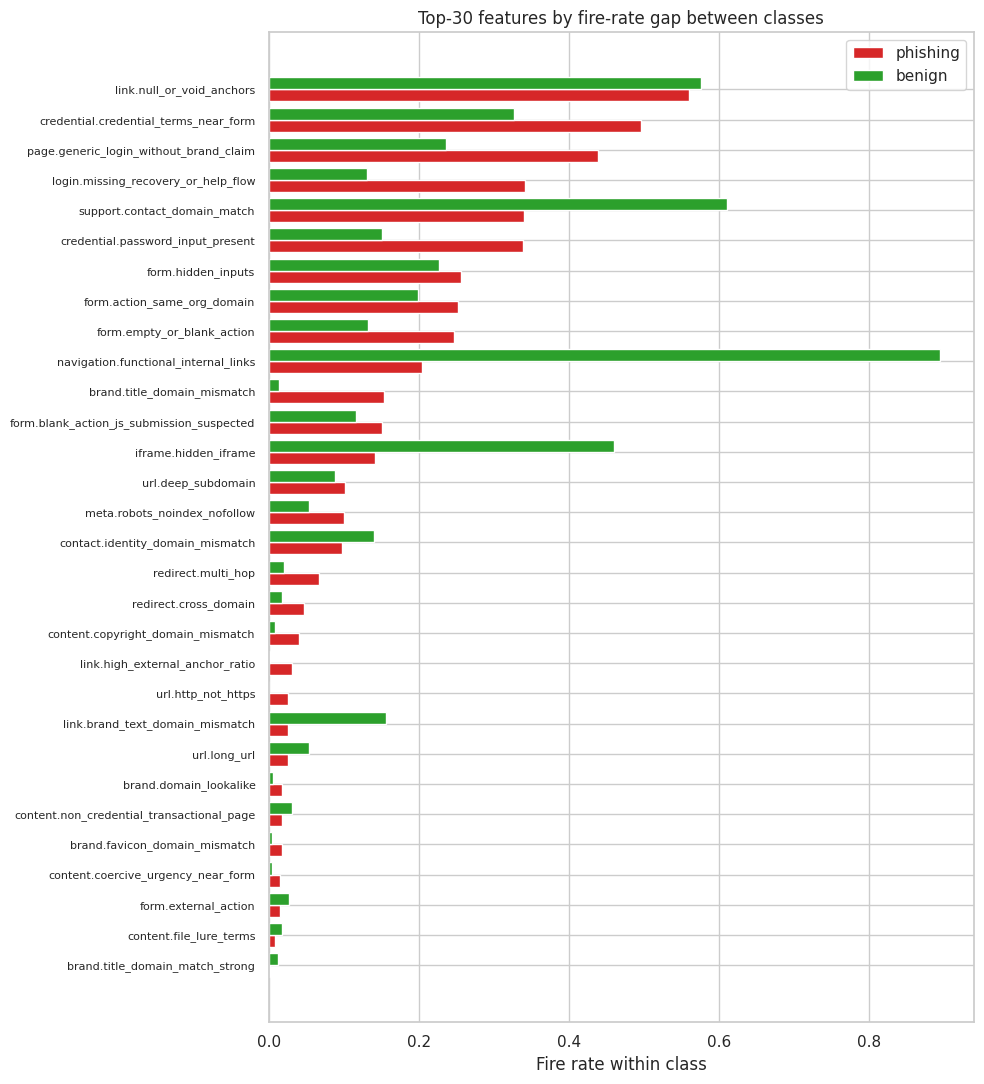

  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/plots/fire_rate_phish_vs_benign.png


In [9]:
ranked = (feature_catalog[feature_catalog['fire_total'] >= 50]
          .assign(abs_diff=lambda d: (d['fire_rate_phish']-d['fire_rate_benign']).abs())
          .sort_values('abs_diff', ascending=False)
          .head(30)
          .sort_values('fire_rate_phish'))

fig, ax = plt.subplots(figsize=(10, 11))
y_pos = np.arange(len(ranked))
ax.barh(y_pos-0.2, ranked['fire_rate_phish'],  0.4, label='phishing', color='#d62728')
ax.barh(y_pos+0.2, ranked['fire_rate_benign'], 0.4, label='benign',   color='#2ca02c')
ax.set_yticks(y_pos); ax.set_yticklabels(ranked['feature_id'], fontsize=8)
ax.set_xlabel('Fire rate within class')
ax.set_title('Top-30 features by fire-rate gap between classes')
ax.legend()
save_plot('fire_rate_phish_vs_benign')

In [10]:
num_cols = [c for c in records_df.columns if c.startswith('m_')]
print(f'Numerical measurement columns: {len(num_cols)}')

rows = []
for c in num_cols:
    a = records_df.loc[records_df['label']=='phishing', c].dropna().astype(float)
    b = records_df.loc[records_df['label']=='benign',   c].dropna().astype(float)
    rows.append({
        'measurement': c[2:],
        'n_phish': len(a), 'n_benign': len(b),
        'median_phish':  float(np.median(a)) if len(a) else None,
        'median_benign': float(np.median(b)) if len(b) else None,
        'mean_phish':    float(np.mean(a))   if len(a) else None,
        'mean_benign':   float(np.mean(b))   if len(b) else None,
        'p99_phish':     float(np.percentile(a, 99)) if len(a) else None,
        'p99_benign':    float(np.percentile(b, 99)) if len(b) else None,
    })
meas_summary = pd.DataFrame(rows)
save_table(meas_summary, 'measurement_summary')
meas_summary

Numerical measurement columns: 21
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/measurement_summary.csv  (21 rows)


,measurement,n_phish,n_benign,median_phish,median_benign,mean_phish,mean_benign,p99_phish,p99_benign
0,url_length,40000,40000,43.0,42.00,53.090525,55.521425,154.0,200.0
1,final_url_length,40000,40000,44.0,43.00,54.169800,62.549775,157.0,419.0
2,hostname_label_count,40000,40000,3.0,3.00,2.796450,2.851925,4.0,4.0
3,redirect_count,40000,40000,0.0,0.00,0.504825,0.129025,2.0,2.0
4,form_count,40000,40000,1.0,1.00,0.888575,1.847400,5.0,14.0
5,credential_form_count,40000,40000,1.0,0.00,0.620525,0.508675,3.0,4.0
6,password_input_count,40000,40000,0.0,0.00,0.689225,0.216500,2.0,3.0
7,hidden_input_count,40000,40000,0.0,0.00,0.798175,1.481225,7.0,21.0
8,form_action_relationship_counts,40000,40000,0.0,0.00,0.269850,0.227800,1.0,1.0
9,anchor_count,40000,40000,5.0,97.00,14.971450,70.953825,100.0,100.0


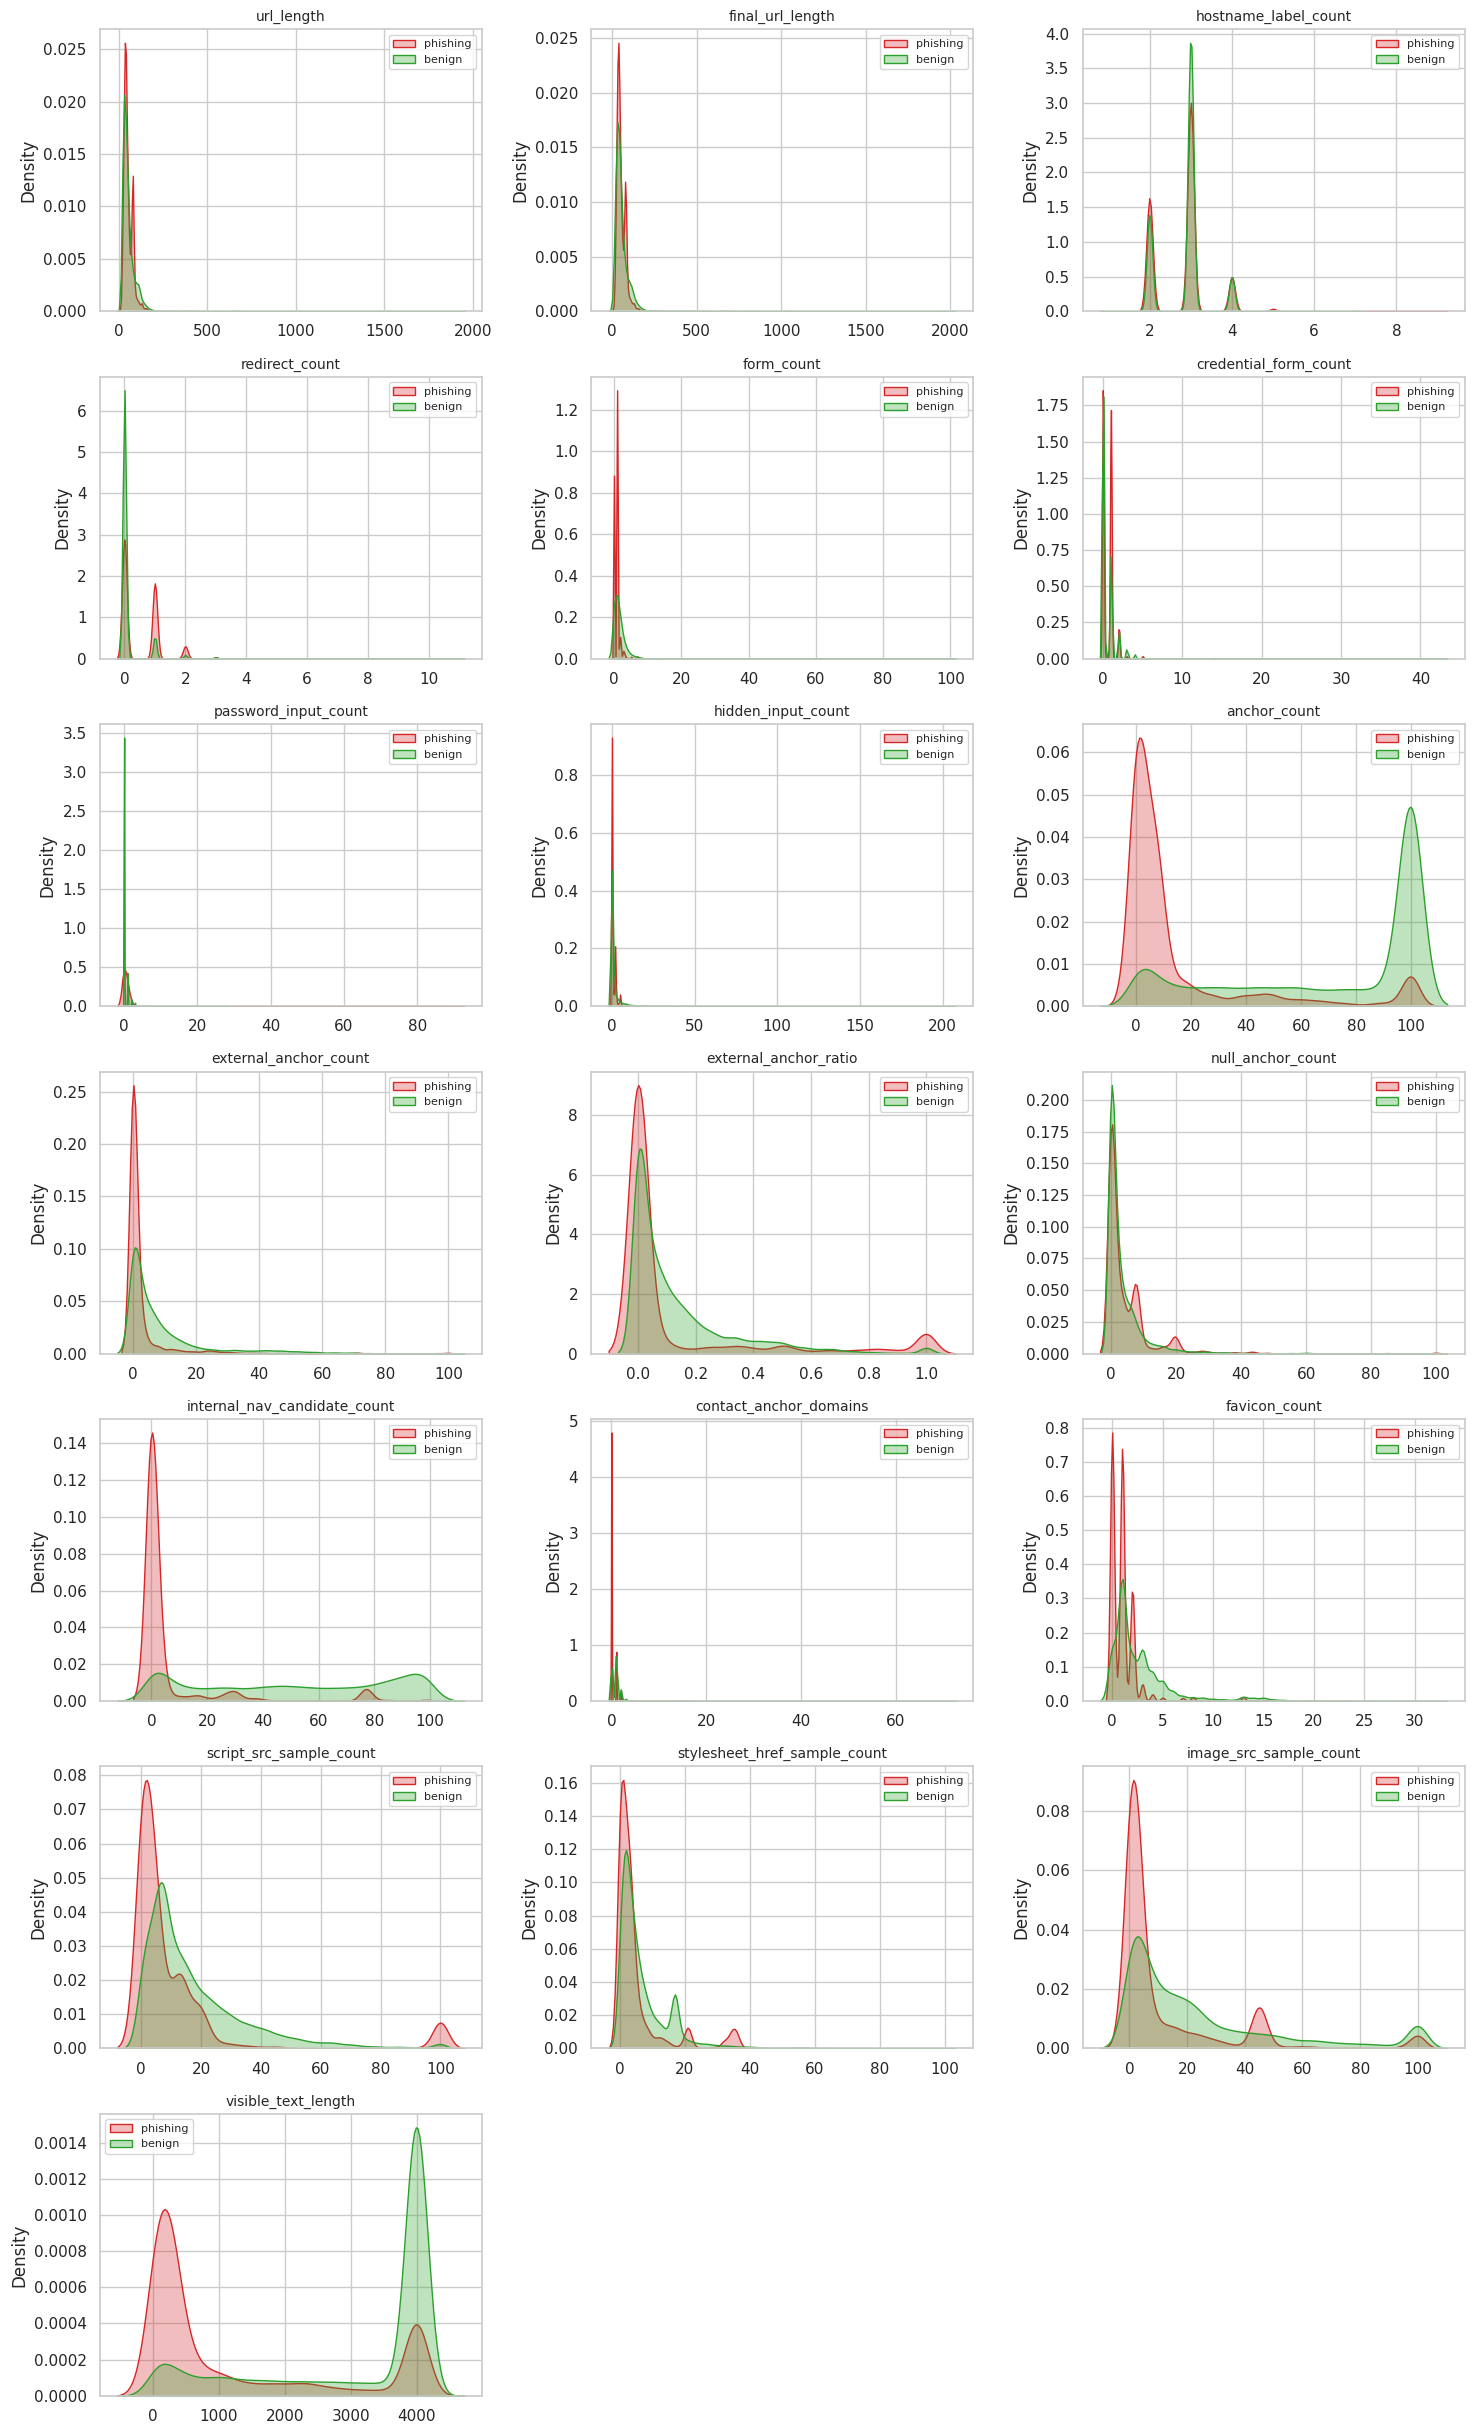

  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/plots/measurement_distributions.png


In [11]:
plot_cols = [c for c in num_cols if records_df[c].dropna().nunique() > 5]
n_per_row = 3
n_rows = int(np.ceil(len(plot_cols) / n_per_row))

fig, axes = plt.subplots(n_rows, n_per_row, figsize=(15, 3.5*n_rows))
axes = np.array(axes).flatten()

for ax, col in zip(axes, plot_cols):
    for lab, color in [('phishing','#d62728'),('benign','#2ca02c')]:
        v = records_df.loc[records_df['label']==lab, col].dropna().astype(float)
        if len(v) < 5: continue
        try:
            sns.kdeplot(v.clip(lower=0), ax=ax, label=lab, color=color, fill=True, alpha=0.3)
        except Exception:
            pass
    ax.set_title(col[2:], fontsize=10); ax.set_xlabel(''); ax.legend(fontsize=8)

for ax in axes[len(plot_cols):]:
    ax.axis('off')
save_plot('measurement_distributions')

In [12]:
import textwrap
print('IQR-based outlier check (1.5×IQR fence):\n')
for c in num_cols:
    s = records_df[c].dropna().astype(float)
    if len(s) < 50 or s.nunique() < 5:
        continue
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    out_mask = (s < lo) | (s > hi)
    print(textwrap.dedent(f'''\
    {c[2:]}
      min={s.min():.2f}  max={s.max():.2f}  median={s.median():.2f}
      IQR fence: [{lo:.2f}, {hi:.2f}]
      outliers: {out_mask.sum():,}  ({out_mask.mean():.1%})
    '''))

IQR-based outlier check (1.5×IQR fence):

url_length
  min=13.00  max=1930.00  median=43.00
  IQR fence: [-17.50, 114.50]
  outliers: 3,852  (4.8%)

final_url_length
  min=13.00  max=2000.00  median=43.00
  IQR fence: [-22.00, 122.00]
  outliers: 3,644  (4.6%)

hostname_label_count
  min=1.00  max=9.00  median=3.00
  IQR fence: [0.50, 4.50]
  outliers: 433  (0.5%)

redirect_count
  min=0.00  max=11.00  median=0.00
  IQR fence: [-1.50, 2.50]
  outliers: 626  (0.8%)

form_count
  min=0.00  max=100.00  median=1.00
  IQR fence: [-1.50, 2.50]
  outliers: 9,718  (12.1%)

credential_form_count
  min=0.00  max=43.00  median=0.00
  IQR fence: [-1.50, 2.50]
  outliers: 2,033  (2.5%)

password_input_count
  min=0.00  max=91.00  median=0.00
  IQR fence: [0.00, 0.00]
  outliers: 19,597  (24.5%)

hidden_input_count
  min=0.00  max=206.00  median=0.00
  IQR fence: [0.00, 0.00]
  outliers: 19,351  (24.2%)

anchor_count
  min=0.00  max=100.00  median=23.00
  IQR fence: [-141.00, 243.00]
  outliers: 0  

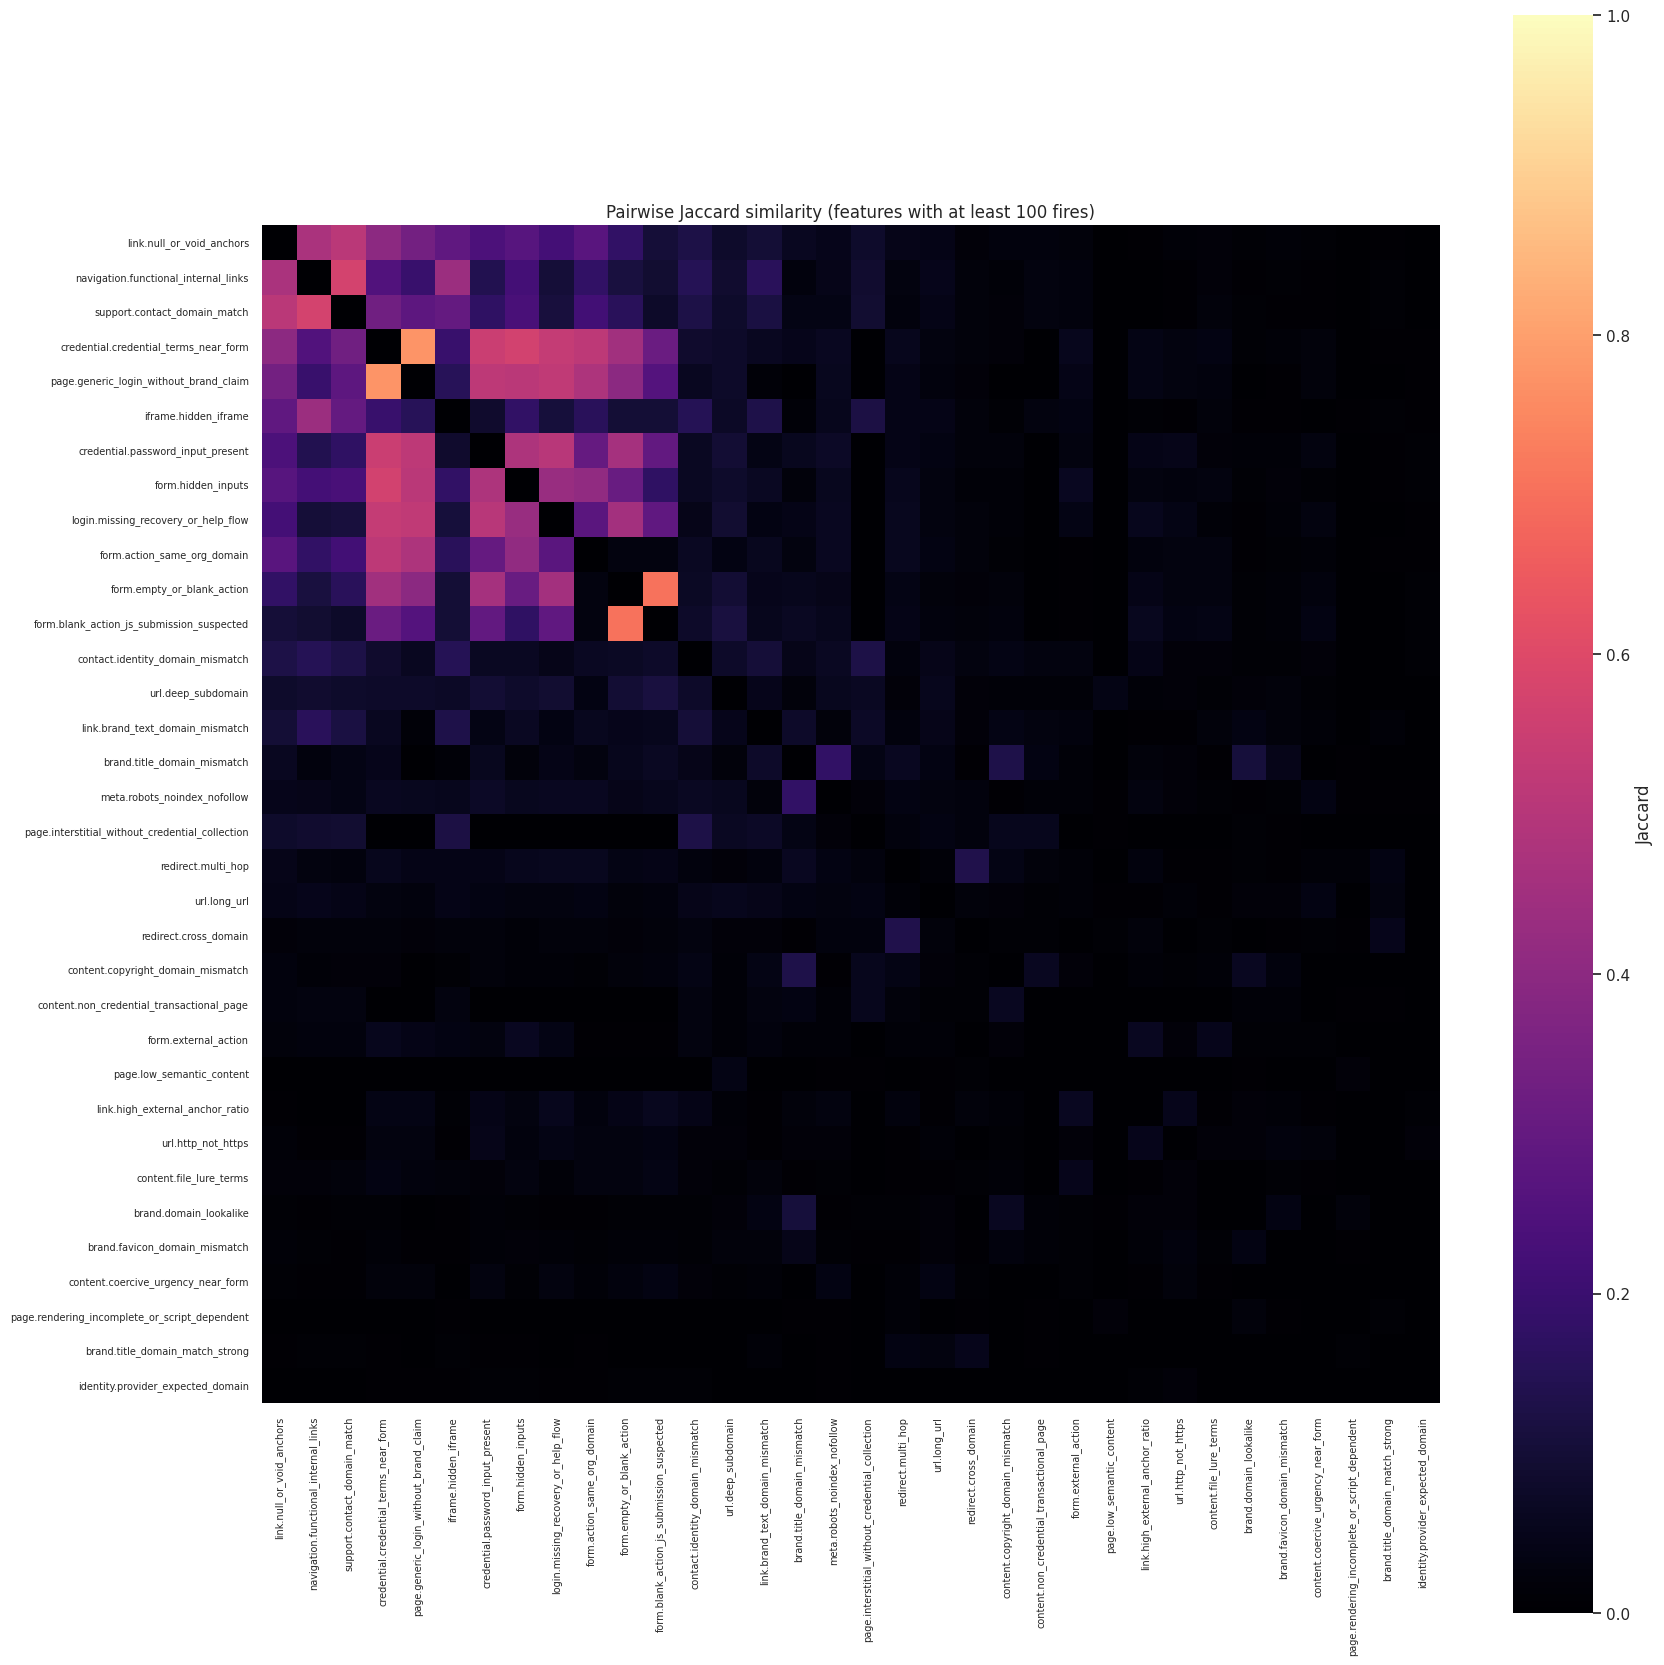

  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/plots/jaccard_heatmap.png
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/redundant_pairs.csv  (0 rows)
Redundant pairs (Jaccard ≥ 0.85): 0


,a,b,jaccard


In [14]:
import scipy.sparse as sp

common = feature_catalog[feature_catalog['fire_total'] >= 100]['feature_id'].tolist()
fid_to_idx = {f: i for i, f in enumerate(common)}

rows_, cols_ = [], []
for ridx, lst in enumerate(fire_lists):
    for fid in lst:
        if fid in fid_to_idx:
            rows_.append(ridx); cols_.append(fid_to_idx[fid])
X = sp.csr_matrix((np.ones(len(rows_), dtype=np.int8), (rows_, cols_)),
                  shape=(len(fire_lists), len(common)))
Xb = X.toarray().astype(bool)

n_feat = Xb.shape[1]
jac = np.zeros((n_feat, n_feat))
for i in range(n_feat):
    a = Xb[:, i]
    for j in range(i+1, n_feat):
        b = Xb[:, j]
        u = (a | b).sum()
        jac[i, j] = jac[j, i] = ((a & b).sum() / u) if u else 0.0

jac_df = pd.DataFrame(jac, index=common, columns=common)
size = min(0.4*len(common)+4, 18)
fig, ax = plt.subplots(figsize=(size, size))
sns.heatmap(jac_df, cmap='magma', vmin=0, vmax=1, square=True,
            cbar_kws={'label':'Jaccard'}, ax=ax)
plt.xticks(rotation=90, fontsize=7); plt.yticks(fontsize=7)
ax.set_title('Pairwise Jaccard similarity (features with at least 100 fires)')
save_plot('jaccard_heatmap')

pairs = []
for i in range(n_feat):
    for j in range(i+1, n_feat):
        if jac[i, j] >= 0.85:
            pairs.append({'a': common[i], 'b': common[j], 'jaccard': round(jac[i,j], 3)})

if pairs:
    redundant = pd.DataFrame(pairs).sort_values('jaccard', ascending=False)
else:
    redundant = pd.DataFrame(columns=['a', 'b', 'jaccard'])
save_table(redundant, 'redundant_pairs')
print(f'Redundant pairs (Jaccard ≥ 0.85): {len(redundant)}')
redundant.head(20)

In [15]:
src_lab = records_df[records_df['label'].isin(['phishing','benign'])].copy()
src_lab['_fired'] = fire_lists[:len(src_lab)]

rows = []
for src, sub in src_lab.groupby('source'):
    if len(sub) < 50: continue
    fc = Counter()
    for lst in sub['_fired']:
        fc.update(lst)
    for fid, c in fc.items():
        rows.append({'source': src,
                     'label': sub['label'].mode().iloc[0],
                     'feature_id': fid,
                     'fire_rate': c / len(sub),
                     'n_in_source': len(sub)})
src_feat = pd.DataFrame(rows)
save_table(src_feat, 'feature_fire_by_source')

pivot = (src_feat.pivot_table(index='feature_id', columns='source',
                              values='fire_rate', aggfunc='mean')
                 .fillna(0))
pivot['range_across_sources'] = pivot.max(axis=1) - pivot.min(axis=1)
src_bias = pivot.sort_values('range_across_sources', ascending=False).head(25)
src_bias.reset_index().pipe(save_table, 'source_bias_top25')
src_bias

  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/feature_fire_by_source.csv  (72 rows)
  saved /content/drive/MyDrive/Colab Notebooks/feature_audit/tables/source_bias_top25.csv  (25 rows)


source,phishing_db.website_content,tranco.websites,range_across_sources
feature_id,,,
navigation.functional_internal_links,0.204900,0.894775,0.689875
iframe.hidden_iframe,0.141225,0.460175,0.318950
support.contact_domain_match,0.340700,0.610575,0.269875
login.missing_recovery_or_help_flow,0.342100,0.130475,0.211625
page.generic_login_without_brand_claim,0.438775,0.236600,0.202175
credential.password_input_present,0.339050,0.150875,0.188175
credential.credential_terms_near_form,0.496550,0.326950,0.169600
brand.title_domain_mismatch,0.153875,0.013775,0.140100
link.brand_text_domain_mismatch,0.026225,0.156250,0.130025


In [16]:
lines = [
    '# Feature Audit Summary',
    f'- Total records: {len(records_df):,}',
    f'- Phishing / benign: {(records_df["label"]=="phishing").sum():,} / {(records_df["label"]=="benign").sum():,}',
    f'- Distinct fired-feature IDs: {len(feature_catalog)}',
    f'- Distinct measurement keys: {len(measurements_catalog)}',
    f'- HTML / SSL / RDAP coverage: {has_html/n:.1%} / {has_ssl/n:.1%} / {has_rdap/n:.1%}',
    '',
    '## Top-10 features by phishing fire rate (min 50 fires)',
]
top10 = (feature_catalog[feature_catalog['fire_total']>=50]
         .sort_values('fire_rate_phish', ascending=False).head(10))
for _, r in top10.iterrows():
    lines.append(f'- `{r["feature_id"]}`  phish={r["fire_rate_phish"]:.1%}  benign={r["fire_rate_benign"]:.1%}  lift={r["lift_phish_over_benign"]}')

lines += ['', '## Top-10 features by benign fire rate (min 50 fires)']
top10b = (feature_catalog[feature_catalog['fire_total']>=50]
          .sort_values('fire_rate_benign', ascending=False).head(10))
for _, r in top10b.iterrows():
    lines.append(f'- `{r["feature_id"]}`  benign={r["fire_rate_benign"]:.1%}  phish={r["fire_rate_phish"]:.1%}')

Path(OUTPUT_DIR, 'AUDIT_SUMMARY.md').write_text('\n'.join(lines))
print('\n'.join(lines))

# Feature Audit Summary
- Total records: 80,000
- Phishing / benign: 40,000 / 40,000
- Distinct fired-feature IDs: 36
- Distinct measurement keys: 22
- HTML / SSL / RDAP coverage: 100.0% / 0.0% / 0.0%

## Top-10 features by phishing fire rate (min 50 fires)
- `link.null_or_void_anchors`  phish=56.0%  benign=57.7%  lift=0.971
- `credential.credential_terms_near_form`  phish=49.7%  benign=32.7%  lift=1.519
- `page.generic_login_without_brand_claim`  phish=43.9%  benign=23.7%  lift=1.855
- `login.missing_recovery_or_help_flow`  phish=34.2%  benign=13.1%  lift=2.622
- `support.contact_domain_match`  phish=34.1%  benign=61.1%  lift=0.558
- `credential.password_input_present`  phish=33.9%  benign=15.1%  lift=2.247
- `form.hidden_inputs`  phish=25.6%  benign=22.7%  lift=1.129
- `form.action_same_org_domain`  phish=25.2%  benign=19.9%  lift=1.268
- `form.empty_or_blank_action`  phish=24.7%  benign=13.3%  lift=1.862
- `navigation.functional_internal_links`  phish=20.5%  benign=89.5%  lift=0.229